In [82]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

IMEI: 869487060202230
V1.0.0.7
V21.2

In [83]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\V5V-791.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1610 non-null   str  
 1   Message  1610 non-null   str  
 2   Status   1610 non-null   str  
dtypes: str(3)
memory usage: 37.9 KB


In [84]:
aux=pd.DataFrame()
aux=raw_data
aux['Headers']='NaN'

for i in range(0,aux.shape[0]):
    aux.iloc[i,3]=aux.iloc[i,2][0:8]

aux['Headers'].value_counts()

Headers
0x252523    598
0x252513    547
0x252514    449
0x252501      9
0x252511      7
Name: count, dtype: int64

In [85]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1610 non-null   str  
 1   Message  1610 non-null   str  
 2   Status   1610 non-null   str  
 3   Headers  1610 non-null   str  
dtypes: str(4)
memory usage: 50.4 KB


Odometer

In [86]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Date']=date
unit_aux['Raw data']=raw

#print(unit_aux['Odometer in meters'])

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 996 entries, 0 to 1609
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Created             996 non-null    str  
 1   Message             996 non-null    str  
 2   Status              996 non-null    str  
 3   Headers             996 non-null    str  
 4   Odometer in meters  996 non-null    int64
 5   Date                996 non-null    str  
 6   Raw data            996 non-null    str  
dtypes: int64(1), str(6)
memory usage: 62.2 KB
None


260923014234 -> 0 -> 4654.0 -> 0x2525130059003C0869487060202230007838402D0000004F4F0000000000640000000000000000FFFFFFFFFFFF00D50000122E00260923014234339B1245AB2B8FC20B2283C10000000003951262FFFFFF0000140000FFFFFF
260923054233 -> 1 -> 4654.0 -> 0x2525130059003D0869487060202230007838402D000000484E0000000000640000000000000000FFFFFFFFFFFF00D50000122E00260923054233339B1245AB2B8FC20B2283C10000000003941257FFFFFF0000110000FFFFFF
260923094234 -> 2 -> 4654.0 -> 0x2525130059003E0869487060202230007838402D0000004F500000000000640000000000000000FFFFFFFFFFFF00D50000122E00260923094234339B1245AB2B8FC20B2283C10000000003941260FFFFFF0000100000FFFFFF
260923094346 -> 3 -> 4654.0 -> 0x252514005900390869487060202230007838402D000000444E0000000000641000000000000000FFFFFFFFFFFF44D50000122E00260923094346339B1245AB2B8FC20B2283C10000000003941262FFFFFF0000100000FFFFFF
260923094424 -> 4 -> 4654.0 -> 0x2525140059003B0869487060202230007838402D00000044CF0000000000641000100000000000FFFFFFFFFFFF79D50000122E00260923094424339

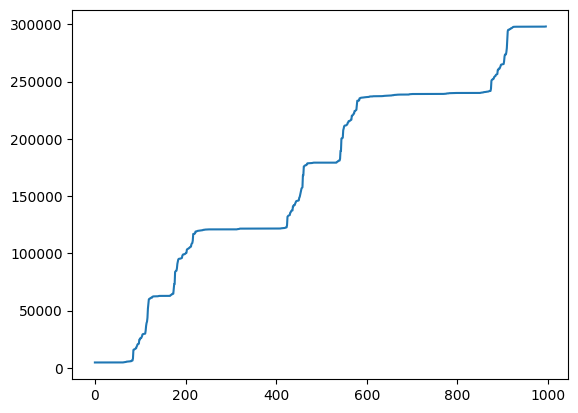

In [87]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,4]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,6])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,len(odometer)):
    print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

#print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

Speed

In [88]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
#unit_aux['Odometer in meters']=0.0
speed=[]
date=[]
raw=[]
unit_speed=pd.DataFrame()
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    try:
        lbs_ind=(bin(int(unit_aux.iloc[i,2][50:52],16) & 64))
        if lbs_ind=='0b1000000':
            speed.append(int(unit_aux.iloc[i,2][142:145]))  
            date.append(unit_aux.iloc[i,2][106:118])
            raw.append(unit_aux.iloc[i,2])
            print(lbs_ind)

    except:
        pass    

unit_speed['Speed']=speed
unit_speed['Date']=date
unit_speed['Raw data']=raw

unit=unit_speed.sort_values('Date',ascending=True)

print(unit.info())

0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000


0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000


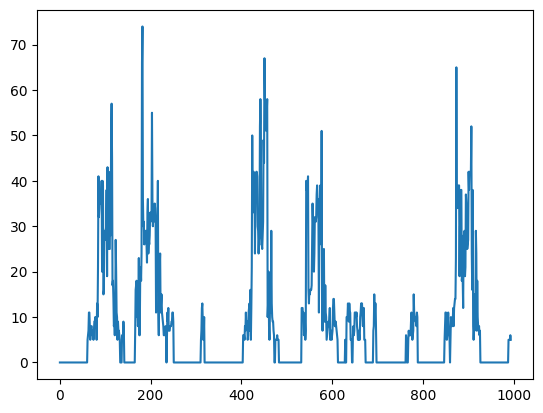

In [89]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,0]))
    x_axis.append(i)
    date.append(unit.iloc[i,1])
    raw_data_.append(unit.iloc[i,2])

plt.plot(x_axis,y_axis)

Historical events

In [90]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 0b10000000)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

print(satellite_connection_indicator)
unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,5]>0:
        num_events=num_events+1
        print(unit.iloc[i,5],'->', unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

[0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 128, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 128, 128, 0, 0, 0, 0, 0, 0, 0, 0, 128, 128, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

Satellites Number

In [91]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 128)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,4]<2:
        num_events=num_events+1
        print(unit.iloc[i,5],'->', unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

<class 'pandas.DataFrame'>
Index: 996 entries, 0 to 1609
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Created                         996 non-null    str  
 1   Message                         996 non-null    str  
 2   Status                          996 non-null    str  
 3   Headers                         996 non-null    str  
 4   Satellites                      996 non-null    int64
 5   Satellite_connection_indicator  996 non-null    int64
 6   Raw data                        996 non-null    str  
 7   date                            996 non-null    str  
dtypes: int64(2), str(6)
memory usage: 70.0 KB
0 -> 2026-09-23 16:59:47.232 -> 0 -> 0x252514005900890869487060202230007838402D00000056000000000000640000000000000000FFFFFFFFFFFF45D50001D8230026092316593582CC000A02CD8267C5A9013A01D2000003941371FFFFFF000029FFFFFFFFFF
Eventos históricos:  1


Coordinates

In [92]:
import struct

unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
latitude=[]
lat_aux=[]
longitude=[]
lon_aux=[]
speed=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    latitude.append(unit_aux.iloc[i,2][134:142])
    longitude.append(unit_aux.iloc[i,2][126:134])
    lon_aux.append(struct.unpack('<f', bytes.fromhex(unit_aux.iloc[i,2][126:134]))[0])
    lat_aux.append(struct.unpack('<f', bytes.fromhex(unit_aux.iloc[i,2][134:142]))[0])    
    speed.append(int(unit_aux.iloc[i,2][142:145],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Latitude']=latitude
unit_aux['Latitude_decoded']=lat_aux
unit_aux['Longitude']=longitude
unit_aux['Longitude_decoded']=lon_aux
unit_aux['Raw data']=raw
unit_aux['Date']=date
unit_aux['Speed']=speed

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

for i in range(0,unit.shape[0]):
    num_events=num_events+1
    print(unit.iloc[i,9],'->', unit.iloc[i,4], '->',unit.iloc[i,5],'->',unit.iloc[i,6],'->',unit.iloc[i,7],unit.iloc[i,8])

<class 'pandas.DataFrame'>
Index: 996 entries, 0 to 1609
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Created            996 non-null    str    
 1   Message            996 non-null    str    
 2   Status             996 non-null    str    
 3   Headers            996 non-null    str    
 4   Latitude           996 non-null    str    
 5   Latitude_decoded   996 non-null    float64
 6   Longitude          996 non-null    str    
 7   Longitude_decoded  996 non-null    float64
 8   Raw data           996 non-null    str    
 9   Date               996 non-null    str    
 10  Speed              996 non-null    int64  
dtypes: float64(2), int64(1), str(8)
memory usage: 93.4 KB
None
260923014234 -> 0B2283C1 -> -16.39162254333496 -> AB2B8FC2 -> -71.58528900146484 0x2525130059003C0869487060202230007838402D0000004F4F0000000000640000000000000000FFFFFFFFFFFF00D50000122E00260923014234339B1245AB2B8FC20B2283C

In/Outs

15      14                 13      12      11      10      09      08       07 06 05 04 03 02 01 00
Power   Ignition/Input0    Input1  Input2  Input3  Input4  Input5  Input0

15=0, Connected
15=1. Disconnected

In [93]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
in_outs=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    aux_raw_data.append(aux_cad[i])
    in_outs.append(bin (int (aux_cad[i][64:68],16) ))      

unit_=pd.DataFrame()
unit_['in and outs']=in_outs
unit_['date']=aux_date
unit_['raw data']=aux_raw_data

in_outs_df=unit_.sort_values('date',ascending=True)

in_outs_df.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\V5V-791_in_outs.csv')

<class 'pandas.DataFrame'>
Index: 996 entries, 0 to 1602
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  996 non-null    str  
 1   Message  996 non-null    str  
 2   Status   996 non-null    str  
 3   Headers  996 non-null    str  
dtypes: str(4)
memory usage: 38.9 KB


Ignition

In [94]:
in_outs_df.info()

for i in range(0,in_outs_df.shape[0]):
    length=len(in_outs_df.iloc[i,0])
    if length>16:
        aux_ign=in_outs_df.iloc[i,0][2:3]
        if aux_ign=='1':
            print("Ignition On",in_outs_df.iloc[i,0])
        if aux_ign=='0':
            print("Ignition Off",in_outs_df.iloc[i,0])
    else:
        aux_ign=in_outs_df.iloc[i,0][2:3]
        if aux_ign=='1':
            print("Ignition On",in_outs_df.iloc[i,0])
        if aux_ign=='0':
            print("Ignition Off",in_outs_df.iloc[i,0])

<class 'pandas.DataFrame'>
Index: 996 entries, 0 to 546
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   in and outs  996 non-null    str  
 1   date         996 non-null    str  
 2   raw data     996 non-null    str  
dtypes: str(3)
memory usage: 31.1 KB
Ignition Off 0b0
Ignition Off 0b0
Ignition Off 0b0
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition

Door detection

In [95]:
x='0b0011000000000000' # for 16 bits, len=18

print(len(x),(x[4:6]))

y='0b011000000000000'   # for 15 bits, len=17
print(len(y), (y[3:5]))


18 11
17 11


In [96]:
in_outs=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\V5V-791_in_outs.csv',sep=',')
in_outs.info()
for i in range(0,in_outs.shape[0]):
    aux=(in_outs.iloc[i,1])
    if len(aux)==18:
        aux_2=(in_outs.iloc[i,1][4:6])
        if aux_2=='11':
            print(in_outs.iloc[i,1],len(aux),aux_2)
    if len(aux)==17:
        aux_2=(in_outs.iloc[i,1][3:5])
        if aux_2=='11':
            print(in_outs.iloc[i,1],len(aux),aux_2)

<class 'pandas.DataFrame'>
RangeIndex: 996 entries, 0 to 995
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Unnamed: 0   996 non-null    int64
 1   in and outs  996 non-null    str  
 2   date         996 non-null    int64
 3   raw data     996 non-null    str  
dtypes: int64(2), str(2)
memory usage: 31.3 KB


Panic detection

In [97]:
unit_.info()

<class 'pandas.DataFrame'>
RangeIndex: 996 entries, 0 to 995
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   in and outs  996 non-null    str  
 1   date         996 non-null    str  
 2   raw data     996 non-null    str  
dtypes: str(3)
memory usage: 23.5 KB


In [98]:
for i in range(0,unit_.shape[0]):
    if unit_.iloc[i,2][92:94]=='42':
        print(unit_.iloc[i,2],unit_.iloc[i,1])

iButton

In [99]:
id_button_m=raw_data[raw_data['Headers'].str.contains('0x252523')]
device_id=[]
id_button_date=[]

for i in range(0,id_button_m.shape[0]):
    device_id.append(id_button_m.iloc[i,2][84:100])
    id_button_date.append(id_button_m.iloc[i,2][32:44])
    print(id_button_m.iloc[i,2][84:100],id_button_m.iloc[i,2][32:44])

id_button_m['date']=id_button_date
id_button_m['device_id']=device_id

yymmdd=[]

for i in range(0,id_button_m.shape[0]):
    yymmdd.append(id_button_m.iloc[i,2][32:38])

id_button_m['yymmdd']=yymmdd
id_button_m.info()

FF00001C74EB4D01 260923094354
FF00001C74EB4D01 260923094355
FF00001C74EB4D01 260923094355
FF00001C74EB4D01 260923094356
FF00001C74EB4D01 260923094356
FF00001C74EB4D01 260923094357
FF00001C74EB4D01 260923094357
FF00001C74EB4D01 260923094358
FF00001C74EB4D01 260923094358
FF00001C74EB4D01 260923094359
FF00001C74EB4D01 260923094359
FF00001C74EB4D01 260923094400
FF00001C74EB4D01 260923094400
FF00001C74EB4D01 260923094401
FF00001C74EB4D01 260923094401
FF00001C74EB4D01 260923094402
FF00001C74EB4D01 260923094403
FF00001C74EB4D01 260923094403
FF00001C74EB4D01 260923094404
FF00001C74EB4D01 260923094404
FF00001C74EB4D01 260923094405
FF00001C74EB4D01 260923094405
FF00001C74EB4D01 260923094406
FF00001C74EB4D01 260923094406
FF00001C74EB4D01 260923094407
FF00001C74EB4D01 260923094407
FF00001C74EB4D01 260923094408
FF00001C74EB4D01 260923094408
FF00001C74EB4D01 260923094409
FF00001C74EB4D01 260923094409
FF00001C74EB4D01 260923094410
FF00001C74EB4D01 260923094410
FF00001C74EB4D01 260923094411
FF00001C74

In [100]:
id_button_m['yymmdd'].value_counts()

yymmdd
260925    360
260923    141
260928     97
Name: count, dtype: int64

log de conductores

In [101]:
log=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\Drivers Log Report_es.xlsx')
sn='V5V-791'
log_v5v_791=log[log['Unidad'].str.contains(sn)]
log_v5v_791

,Conductor,Unidad,Unnamed: 2,Entrada,Unnamed: 4,Dirección / Landmark,Unnamed: 6,Unnamed: 7,Unnamed: 8,Salida,Unnamed: 10,Dirección / Landmark.1
28,"ARAPA ARAPA, HENRY JAVIER",V5V-791,NaN,23/09/2026 04:43 a.m.,NaN,"Av Pe-34 A-48, Cerro Colorado, Arequipa, Arequ...",NaN,NaN,NaN,25/09/2026 02:11 p.m.,NaN,"Av Pe-34 A-51, Cerro Colorado, Arequipa, Arequ..."
29,"ARAPA ARAPA, HENRY JAVIER",V5V-791,NaN,28/09/2026 04:31 a.m.,NaN,"Av Pe-34 A-54, Cerro Colorado, Arequipa, Arequ...",NaN,NaN,NaN,NaN,NaN,NaN


In [102]:
hl=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\hl_V5V-791.xlsx')
hl['Eventos'].value_counts()

Eventos
Desplazándose - Ign. apagada    117
Estacionado                      82
iButton Conectado                52
Entrada 2 Desactivada             5
Entrada 2 Activada                5
Entrando a Landmark               5
Saliendo de Landmark              4
Name: count, dtype: int64